In [ ]:
import os,warnings,pyreadstat
import pandas as pd 
import numpy as np 
#pyreadstat(python + read + statistical data)으로 sas나 spss 파일 읽어오는 도구
warnings.filterwarnings('ignore')
# 사소한 버전 불일치 경고같은거 무시

In [ ]:
file_path=r"C:\knhanes\hn24_all.sas7bdat"
# r를 사용하여 \뒤에 \n이나 \t같이 시작할때 줄바꿈이나 탭으로 인식 안하게 해줌

df_24, meta=pyreadstat.read_sas7bdat(file_path)

print(f"2024년 데이터 크기: {df_24.shape}")
df_24.head()

2024년 데이터 크기: (6997, 813)


,mod_d,ID,ID_fam,year,region,town_t,apt_t,psu,sex,age,...,HEI_VEG,HEI_PROTF,HEI_DAIRY,HEI_SFA,HEI_NA,HEI_SUGAR,HEI_CHO,HEI_FAT,HEI_EN,HEI
0,2026.07.31.,WA01257801,WA012578,2024.0,1.0,1.0,2.0,WA01,1.0,38.0,...,2.506099,10.000000,1.842506,0.0,10.0,10.0,0.0,0.0,3.499089,39.457606
1,2026.07.31.,WA01257802,WA012578,2024.0,1.0,1.0,2.0,WA01,2.0,34.0,...,1.950125,2.663838,0.000000,10.0,10.0,10.0,5.0,5.0,0.000000,57.997990
2,2026.07.31.,WA01257803,WA012578,2024.0,1.0,1.0,2.0,WA01,1.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026.07.31.,WA01257804,WA012578,2024.0,1.0,1.0,2.0,WA01,1.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026.07.31.,WA01257805,WA012578,2024.0,1.0,1.0,2.0,WA01,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
selected_cols = [
    'ID', 'year', 'age', 'sex', 'incm', 'edu',
    'DI1_dg', 'DI1_pt', 'DE1_dg', 'DE1_pt', 'DI2_dg', 'DI2_pt',
    'HE_glu', 'HE_TG', 'HE_HDL_st2', 'HE_sbp', 'HE_dbp',
    'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc',
    'sm_presnt', 'dr_month', 'pa_aerobic'
]

df_list = []
years = ['21', '22', '23', '24']

for y in years:
    fpath=f'C:\\knhanes\\hn{y}_all.sas7bdat'
    if os.path.exists(fpath):
        print(f'20{y}년 데이터 가져오는 중')
        temp_df, _ = pyreadstat.read_sas7bdat(fpath) 
        # 위에서는 df_24랑 meta 두개의 변수로 받았었다 meta에는 중성지방이나 흡연등 
        # 어떻게 표시해두었는지에 대한 설명을 담고있었다
        # 지금은 필요한 컬럼들만 뽑는 작업이기에 meta데이터는 필요가 없어 _로 표시하였다
        valid_cols=[c for c in selected_cols if c in temp_df.columns]
        df_list.append(temp_df[valid_cols])

df_all=pd.concat(df_list,axis=0,ignore_index=True)
df_all.head()

2021년 데이터 가져오는 중
2022년 데이터 가져오는 중
2023년 데이터 가져오는 중
2024년 데이터 가져오는 중


,ID,year,age,sex,incm,edu,DI1_dg,DI1_pt,DE1_dg,DE1_pt,...,HE_HDL_st2,HE_sbp,HE_dbp,HE_ht,HE_wt,HE_BMI,HE_wc,sm_presnt,dr_month,pa_aerobic
0,A901215301,2021.0,61.0,1.0,3.0,3.0,1.0,1.0,0.0,8.0,...,61.0,137.5,82.5,179.9,86.7,26.789017,103.7,0.0,1.0,1.0
1,A901215302,2021.0,57.0,1.0,2.0,3.0,1.0,0.0,0.0,8.0,...,49.0,158.0,102.0,179.3,82.0,25.506641,92.6,0.0,1.0,1.0
2,A901225501,2021.0,39.0,2.0,1.0,2.0,0.0,8.0,0.0,8.0,...,45.0,104.5,67.5,159.9,59.0,23.075711,79.3,0.0,1.0,1.0
3,A901225502,2021.0,19.0,2.0,2.0,3.0,0.0,8.0,0.0,8.0,...,41.0,98.0,61.0,169.7,63.1,21.911175,74.3,0.0,1.0,1.0
4,A901227201,2021.0,70.0,1.0,2.0,2.0,0.0,8.0,0.0,8.0,...,51.0,105.5,69.0,171.4,55.8,18.993831,72.7,1.0,0.0,0.0


In [ ]:
df_young=df_all[(df_all['age']>=19)&(df_all['age']<=39)].copy()
print(f'19~39세 청년층 인원: {len(df_young):,}명')
# len뒤에 ,를 붙이면 5341이 아닌 5,341같이 천 단위로 콤마찍어줌

med_mask = (df_young['DI1_pt'] == 1) | (df_young['DE1_pt'] == 1) | (df_young['DI2_pt'] == 1)
# pt는 약물 복용 및 치료자

df_study = df_young[~med_mask].copy()
# ~는 제외하고라는 의미
print(f"약 복용자 제외 후 최종 연구 대상자: {len(df_study):,}명")

19~39세 청년층 인원: 5,341명
약 복용자 제외 후 최종 연구 대상자: 5,204명


In [ ]:
cond_glu=(df_study['HE_glu']>=100)
# 공복혈당은 100미만이 정상
cond_bp = (df_study['HE_sbp'] >= 130) | (df_study['HE_dbp'] >= 85)
# 혈압
cond_tg = (df_study['HE_TG'] >= 150)
# 중성지방 쉽게 말하면 혈액 속 나쁜 기름
cond_hdl = ((df_study['sex'] == 1) & (df_study['HE_HDL_st2'] < 40)) | ((df_study['sex'] == 2) & (df_study['HE_HDL_st2'] < 50))
# 좋은 콜레스테롤 남자는 40미만이면 위험 여자는 50미만이면 위험, 호로몬 차이 때문에 기준치를 다르게 설정
is_abnormal= cond_glu | cond_bp | cond_tg | cond_hdl
df_study['Target']= np.where(is_abnormal,1,0)

print(df_study['Target'].value_counts())

print((df_study['Target'].value_counts(normalize=True) * 100).round(1))


Target
0    3321
1    1883
Name: count, dtype: int64
Target
0    63.8
1    36.2
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

df_study['WHtR']=df_study['HE_wc']/df_study['HE_ht']
# 허리둘레/키
# bmi는 근육이 많아도 높게 잡혀서 무의미함

features = [
    'age', 'sex', 'incm', 'edu',
    'HE_BMI', 'HE_wc', 'WHtR',
    'sm_presnt', 'dr_month', 'pa_aerobic'
]
# 추후 헬스케어 앱에 적용가능할것인가에 대해서 입증하기 위해 간단한 정보로 실험

data_clean = df_study.dropna(subset=features + ['Target']).copy()
#subset+target을 통하여 다른 열을 검사하지 않고 target열에서만 검사하여 메모리 절약

X = data_clean[features]
y = data_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify를 사용하여 훈련셋이랑 테스트셋 나눌때 위험군 비율에 맞게 분할해주어서 쏠림 방지
print(f'\n훈련 데이터 크기(X_train):{X_train.shape}')
print(f'시험 데이터 크기(X_test):{X_test.shape}')


훈련 데이터 크기(X_train):(3276, 10)
시험 데이터 크기(X_test):(1404, 10)


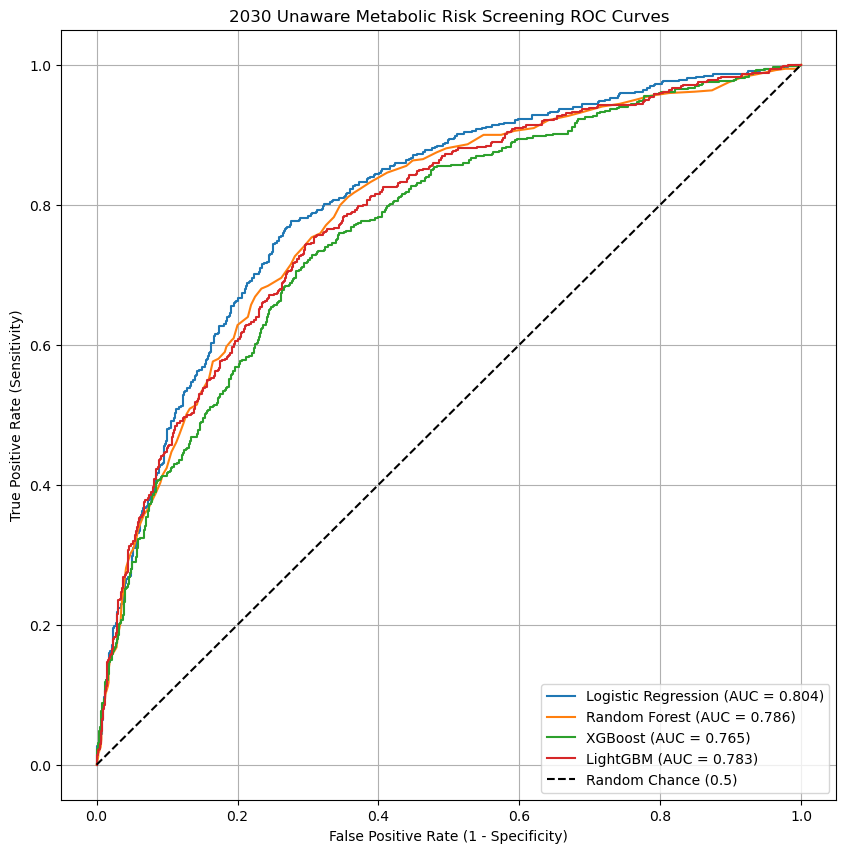

=== 모델별 최종 성능 비교표 ===
              Model  ROC-AUC   PR-AUC
Logistic Regression 0.803666 0.695653
      Random Forest 0.786287 0.669922
           LightGBM 0.782822 0.676910
            XGBoost 0.765383 0.661108


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

os.environ['LOKY_MAX_CPU_COUNT']=str(os.cpu_count() or 4)

# 비교 모델 4개
# 로지스틱은 의학 통계의 기준선
# 랜덤 포레스트 트리구조
# XGBoost 오차를 수정하는 그래디언트 모델
# LightGBM 분석 속도가 매우 빠름 현재 데이터분석시 가장 효율적
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results=[]
plt.figure(figsize=(10,10))

for name,model in models.items():
    model.fit(X_train,y_train)

    y_pred_proba=model.predict_proba(X_test)[:,1]

    auc= roc_auc_score(y_test, y_pred_proba)
    pr_auc=average_precision_score(y_test,y_pred_proba)
    results.append({'Model': name, 'ROC-AUC': auc, 'PR-AUC': pr_auc})
    # ROC-AUC는 정상인을 정상인이라고 맞춘 확률도 포함
    # PR-AUC는 오직 환자를 환자라고 맞춘 확률만 보여줌

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('2030 Unaware Metabolic Risk Screening ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


result_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("=== 모델별 최종 성능 비교표 ===")
print(result_df.to_string(index=False))

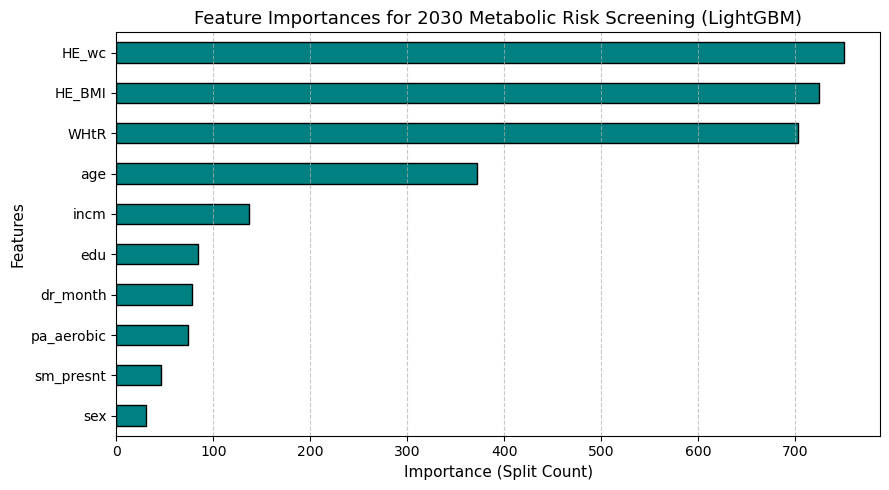

=== 변수 중요도 순위 (높은 순) ===
HE_wc         750
HE_BMI        725
WHtR          703
age           372
incm          137
edu            84
dr_month       78
pa_aerobic     74
sm_presnt      46
sex            31


In [ ]:
#LightGBM 모델은 트리 기반임으로 판별할때 어떤 수치를 유심히 봤나 보기 위하여 사용
best_model = models['LightGBM']
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Feature Importances for 2030 Metabolic Risk Screening (LightGBM)', fontsize=13)
plt.xlabel('Importance (Split Count)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("=== 변수 중요도 순위 (높은 순) ===")
print(importances.sort_values(ascending=False).to_string())

In [ ]:
from scipy import stats

# 비교할 주요 변수들 정의 (연속형 변수와 범주형 변수)
cont_vars = ['age', 'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc', 'WHtR', 'HE_glu', 'HE_sbp', 'HE_dbp', 'HE_TG', 'HE_HDL_st2']
cat_vars = ['sex', 'incm', 'sm_presnt', 'dr_month', 'pa_aerobic']

table1_rows = []

# 연속형 변수 t-test 및 Mean ± SD 계산
for var in cont_vars:
    g0 = data_clean[data_clean['Target'] == 0][var].dropna()
    g1 = data_clean[data_clean['Target'] == 1][var].dropna()
    
    # 두 집단 독립표본 t-검정
    stat, pval = stats.ttest_ind(g0, g1, equal_var=False)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    table1_rows.append({
        'Variable': var,
        'Normal Group (Target=0)': f"{g0.mean():.1f} ± {g0.std():.1f}",
        'Risk Group (Target=1)': f"{g1.mean():.1f} ± {g1.std():.1f}",
        'p-value': p_str
    })

for var in cat_vars:
    ct = pd.crosstab(data_clean[var], data_clean['Target'])
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    # 1인 비율(예: 남성 비율, 흡연율, 음주율 등)
    pct0 = (data_clean[data_clean['Target'] == 0][var] == 1).mean() * 100
    pct1 = (data_clean[data_clean['Target'] == 1][var] == 1).mean() * 100
    
    table1_rows.append({
        'Variable': f"{var} (Yes %)",
        'Normal Group (Target=0)': f"{pct0:.1f}%",
        'Risk Group (Target=1)': f"{pct1:.1f}%",
        'p-value': p_str
    })

table1_df = pd.DataFrame(table1_rows)
print("=== Table 1: Baseline Characteristics of Study Population ===")
table1_df

=== Table 1: Baseline Characteristics of Study Population ===


,Variable,Normal Group (Target=0),Risk Group (Target=1),p-value
0,age,28.6 ± 5.9,30.7 ± 5.8,< 0.001
1,HE_ht,167.0 ± 8.3,169.8 ± 8.7,< 0.001
2,HE_wt,62.3 ± 12.8,76.0 ± 16.4,< 0.001
3,HE_BMI,22.2 ± 3.5,26.2 ± 4.7,< 0.001
4,HE_wc,75.6 ± 9.8,87.9 ± 12.2,< 0.001
5,WHtR,0.5 ± 0.1,0.5 ± 0.1,< 0.001
6,HE_glu,88.5 ± 5.8,97.8 ± 20.8,< 0.001
7,HE_sbp,108.1 ± 9.3,117.8 ± 13.0,< 0.001
8,HE_dbp,68.0 ± 6.6,75.3 ± 10.1,< 0.001
9,HE_TG,76.8 ± 27.4,166.3 ± 118.5,< 0.001


수학적 최적의 위험 판정 기준치(Threshold): 0.349
모델의 민감도(Sensitivity, 질환 포착률) : 77.6%
모델의 특이도(Specificity, 정상 감별률) : 72.4%



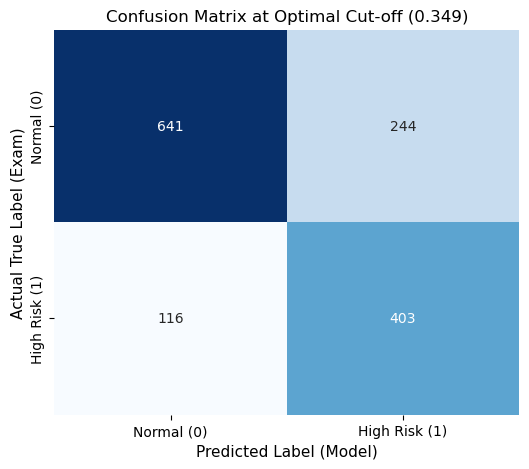

=== 상세 분류 성능 보고서 ===
              precision    recall  f1-score   support

      Normal       0.85      0.72      0.78       885
   High Risk       0.62      0.78      0.69       519

    accuracy                           0.74      1404
   macro avg       0.73      0.75      0.74      1404
weighted avg       0.76      0.74      0.75      1404



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 로지스틱 회귀의 시험 데이터 예측 확률 가져오기
lr_model = models['Logistic Regression']
y_proba = lr_model.predict_proba(X_test)[:, 1]

# 유덴지수로 수학적 최적의 임계치 계산
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
opt_idx = np.argmax(youden_j)
opt_threshold = thresholds[opt_idx]

# 최적 기준치를 적용한 예측값 결정 (0 또는 1)
y_pred_opt = (y_proba >= opt_threshold).astype(int)

# 혼동행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
# ravel함수는 1차원 평면으로 펼쳐서 변수에 넣음

sensitivity = tp / (tp + fn)  # 민감도 (진짜 위험군을 맞힌 비율)
specificity = tn / (tn + fp)  # 특이도 (정상인을 정상으로 맞힌 비율)

print(f"수학적 최적의 위험 판정 기준치(Threshold): {opt_threshold:.3f}")
print(f"모델의 민감도(Sensitivity, 질환 포착률) : {sensitivity * 100:.1f}%")
print(f"모델의 특이도(Specificity, 정상 감별률) : {specificity * 100:.1f}%\n")


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'High Risk (1)'],
            yticklabels=['Normal (0)', 'High Risk (1)'])
plt.title(f'Confusion Matrix at Optimal Cut-off ({opt_threshold:.3f})', fontsize=12)
plt.xlabel('Predicted Label (Model)', fontsize=11)
plt.ylabel('Actual True Label (Exam)', fontsize=11)
plt.show()

print("=== 상세 분류 성능 보고서 ===")
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'High Risk']))

In [ ]:
# 로지스틱 회귀 계수(Beta)와 오즈비(Odds Ratio = exp(Beta)) 계산
coef = lr_model.coef_[0]
odds_ratios = np.exp(coef)

# 2. 통계적 95% 신뢰구간 근사 계산 (Standard Error 추정)
# 디자인 행렬 X에 절편(상수항) 추가
X_mat = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
p_train = lr_model.predict_proba(X_train)[:, 1]
V = p_train * (1 - p_train)
cov = np.linalg.inv(np.dot(X_mat.T, X_mat * V[:, np.newaxis]))
se = np.sqrt(np.diag(cov))[1:]  # 절편 제외한 각 변수의 표준오차

# 95% 신뢰구간 (CI) 및 z-score, p-value 계산
ci_lower = np.exp(coef - 1.96 * se)
ci_upper = np.exp(coef + 1.96 * se)
z_scores = coef / se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))


or_df = pd.DataFrame({
    'Variable': features,
    'Beta (계수)': coef.round(3),
    'Odds Ratio (aOR)': odds_ratios.round(3),
    '95% CI (하한 ~ 상한)': [f"{l:.3f} ~ {u:.3f}" for l, u in zip(ci_lower, ci_upper)],
    'p-value': ["< 0.001" if p < 0.001 else f"{p:.3f}" for p in p_values]
}).sort_values(by='Odds Ratio (aOR)', ascending=False)

print("=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===")
print(or_df.to_string(index=False))

=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===
  Variable  Beta (계수)  Odds Ratio (aOR) 95% CI (하한 ~ 상한) p-value
      WHtR      1.151             3.160  0.013 ~ 754.736   0.680
 sm_presnt      0.396             1.485    1.187 ~ 1.858 < 0.001
     HE_wc      0.098             1.103    1.068 ~ 1.139 < 0.001
       sex      0.096             1.101    0.845 ~ 1.436   0.476
       age      0.045             1.046    1.030 ~ 1.063 < 0.001
    HE_BMI     -0.007             0.993    0.937 ~ 1.053   0.815
      incm     -0.052             0.950    0.880 ~ 1.025   0.183
pa_aerobic     -0.131             0.878    0.738 ~ 1.044   0.141
  dr_month     -0.167             0.847    0.710 ~ 1.009   0.063
       edu     -0.192             0.825    0.694 ~ 0.980   0.029


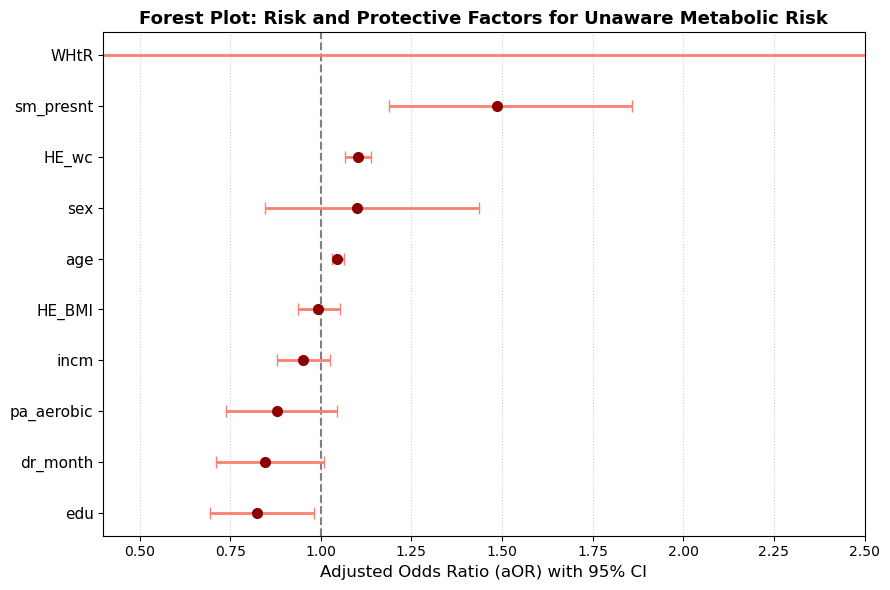

In [ ]:
# 정렬된 오즈비 데이터 준비 (상수항 제외)
plot_df = or_df.sort_values(by='Odds Ratio (aOR)', ascending=True).copy()

plt.figure(figsize=(9, 6))

# 기준선 1.0 그리기 (1.0보다 크면 위험 요인, 작으면 보호 요인)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (OR = 1.0)')


y_pos = range(len(plot_df))
ci_lowers = [float(ci.split(' ~ ')[0]) for ci in plot_df['95% CI (하한 ~ 상한)']]
ci_uppers = [float(ci.split(' ~ ')[1]) for ci in plot_df['95% CI (하한 ~ 상한)']]
errors = [
    plot_df['Odds Ratio (aOR)'] - ci_lowers,
    ci_uppers - plot_df['Odds Ratio (aOR)']
]

plt.errorbar(plot_df['Odds Ratio (aOR)'], y_pos, xerr=errors, fmt='o', 
             color='darkred', ecolor='salmon', elinewidth=2, capsize=4, markersize=7)

plt.yticks(y_pos, plot_df['Variable'], fontsize=11)
plt.xlim(0.4, 2.5)  # 직관적 비교를 위한 범위 설정
plt.xlabel('Adjusted Odds Ratio (aOR) with 95% CI', fontsize=12)
plt.title('Forest Plot: Risk and Protective Factors for Unaware Metabolic Risk', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

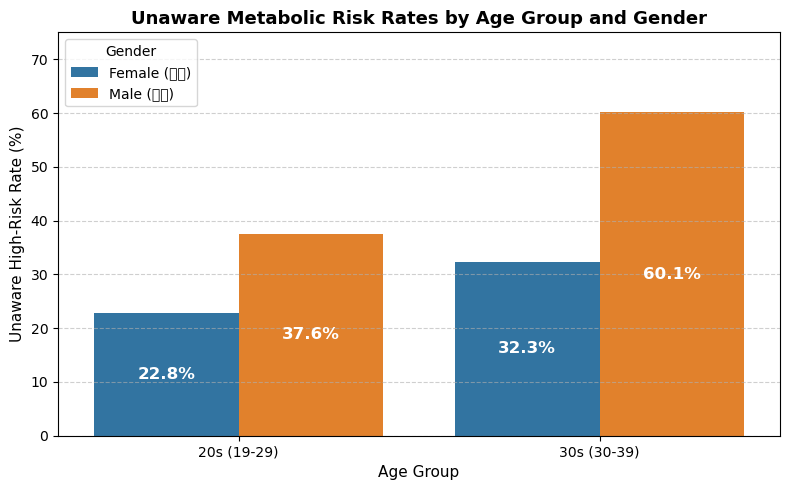

20대 전용 모델 예측 성능(ROC-AUC): 0.779
30대 전용 모델 예측 성능(ROC-AUC): 0.808
20대 흡연 위험 계수: 0.303
30대 흡연 위험 계수: 0.484


In [ ]:
# 20대(19~29세)와 30대(30~39세) 그룹 나누기
data_clean['age_group'] = np.where(data_clean['age'] < 30, '20s (19-29)', '30s (30-39)')
data_clean['gender'] = np.where(data_clean['sex'] == 1, 'Male (남성)', 'Female (여성)')

# 성별 x 연령대별 미인지 대사이상 위험군 비율(%) 집계
sub_stats = data_clean.groupby(['gender', 'age_group'])['Target'].agg(['count', 'mean']).reset_index()
sub_stats['Risk_Pct'] = sub_stats['mean'] * 100


plt.figure(figsize=(8, 5))
bar_plot = sns.barplot(data=sub_stats, x='age_group', y='Risk_Pct', hue='gender', palette=['#1f77b4', '#ff7f0e'])


for p in bar_plot.patches:
    height = p.get_height()
    if height > 0:
        bar_plot.annotate(f'{height:.1f}%', 
                          (p.get_x() + p.get_width() / 2., height / 2),
                          ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.title('Unaware Metabolic Risk Rates by Age Group and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Unaware High-Risk Rate (%)', fontsize=11)
plt.ylim(0, 75)
plt.legend(title='Gender', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. 20대 모델 vs 30대 모델 성능 및 요인 차이 출력
d20 = data_clean[data_clean['age'] < 30]
d30 = data_clean[data_clean['age'] >= 30]
sub_feats = ['sex', 'incm', 'edu', 'HE_BMI', 'HE_wc', 'WHtR', 'sm_presnt', 'dr_month', 'pa_aerobic']

m20 = LogisticRegression(max_iter=1000).fit(d20[sub_feats], d20['Target'])
m30 = LogisticRegression(max_iter=1000).fit(d30[sub_feats], d30['Target'])

auc20 = roc_auc_score(d20['Target'], m20.predict_proba(d20[sub_feats])[:, 1])
auc30 = roc_auc_score(d30['Target'], m30.predict_proba(d30[sub_feats])[:, 1])

print(f"20대 전용 모델 예측 성능(ROC-AUC): {auc20:.3f}")
print(f"30대 전용 모델 예측 성능(ROC-AUC): {auc30:.3f}")
print(f"20대 흡연 위험 계수: {m20.coef_[0][sub_feats.index('sm_presnt')]:.3f}")
print(f"30대 흡연 위험 계수: {m30.coef_[0][sub_feats.index('sm_presnt')]:.3f}")